# London House Price Prediction - Prompt A Solution

This notebook follows the required 4 stages:
1. Data ingestion and quality assessment
2. Exploratory data analysis
3. Baseline models
4. Performance improvement

All random operations use `random_state=42` for reproducibility.

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
BASE_DIR = Path.cwd()
prices_path = BASE_DIR / "london_house_prices.csv"
areas_path = BASE_DIR / "london_area_features.csv"

print("Working directory:", BASE_DIR)
print("Prices exists:", prices_path.exists())
print("Areas exists:", areas_path.exists())

Working directory: c:\Users\Dath\OneDrive\Desktop\AntiGravity Stuff\PREDICTIVE\copilot
Prices exists: True
Areas exists: True


## Stage 1 - Data Ingestion and Quality Assessment

In [2]:
prices = pd.read_csv(prices_path)
areas = pd.read_csv(areas_path)

print("prices shape:", prices.shape)
print("areas shape:", areas.shape)

print("\nprices dtypes:\n", prices.dtypes)
print("\nareas dtypes (first 20):\n", areas.dtypes.head(20))


def missing_summary(df, name):
    miss = df.isna().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    summary = pd.DataFrame({
        "missing_count": miss,
        "missing_pct": (miss / len(df) * 100).round(2)
    })
    print(f"\n{name} missing summary:")
    if summary.empty:
        print("No missing values.")
    else:
        display(summary)


missing_summary(prices, "prices")
missing_summary(areas, "areas")

q1 = prices["price"].quantile(0.25)
q3 = prices["price"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
outlier_mask = (prices["price"] < lower) | (prices["price"] > upper)
print(f"\nPrice outliers by IQR rule: {outlier_mask.sum():,} ({100*outlier_mask.mean():.2f}%)")
print("Outlier handling strategy: keep rows but cap target at 1st/99th percentile for improved models.")

# Merge and basic quality checks
merged = prices.merge(areas, on="outcode", how="left", indicator=True)
print("\nMerged shape:", merged.shape)
print("Merge indicator counts:\n", merged["_merge"].value_counts())
merged = merged.drop(columns=["_merge"])

# Remove rows with missing/non-positive target only
before = len(merged)
merged = merged[merged["price"].notna() & (merged["price"] > 0)].copy()
after = len(merged)
print(f"Rows after quality filtering: {after:,} (removed {before-after:,})")

prices shape: (417561, 12)
areas shape: (168, 52)

prices dtypes:
 outcode          object
latitude        float64
longitude       float64
bedrooms        float64
bathrooms       float64
floorAreaSqM    float64
livingRooms     float64
propertyType     object
tenure           object
energyRating     object
rentEstimate    float64
price           float64
dtype: object

areas dtypes (first 20):
 outcode                                object
outcode_lat                           float64
outcode_lon                           float64
n_properties                            int64
crime_anti_social_behaviour             int64
crime_bicycle_theft                     int64
crime_burglary                          int64
crime_criminal_damage_and_arson         int64
crime_drugs                             int64
crime_other_crime                       int64
crime_other_theft                       int64
crime_possession_of_weapons             int64
crime_public_order                      int64
crime_

,missing_count,missing_pct
energyRating,84288,20.19
bathrooms,77755,18.62
livingRooms,60341,14.45
bedrooms,40404,9.68
floorAreaSqM,25066,6.00
tenure,11494,2.75
propertyType,1126,0.27
rentEstimate,1101,0.26



areas missing summary:
No missing values.

Price outliers by IQR rule: 37,210 (8.91%)
Outlier handling strategy: keep rows but cap target at 1st/99th percentile for improved models.

Merged shape: (417561, 64)
Merge indicator counts:
 _merge
both          417561
left_only          0
right_only         0
Name: count, dtype: int64
Rows after quality filtering: 417,561 (removed 0)


In [4]:
# Ensure plot output directory exists for later cells
plot_dir = BASE_DIR / "plots_prompt_a"
plot_dir.mkdir(exist_ok=True)

## Stage 2 - Exploratory Data Analysis

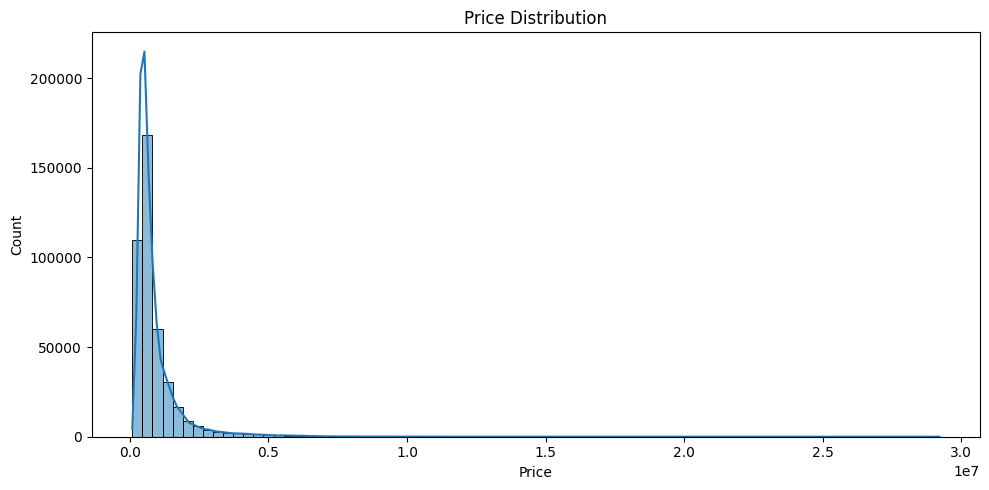

Comment: The distribution is strongly right-skewed with a long high-price tail.


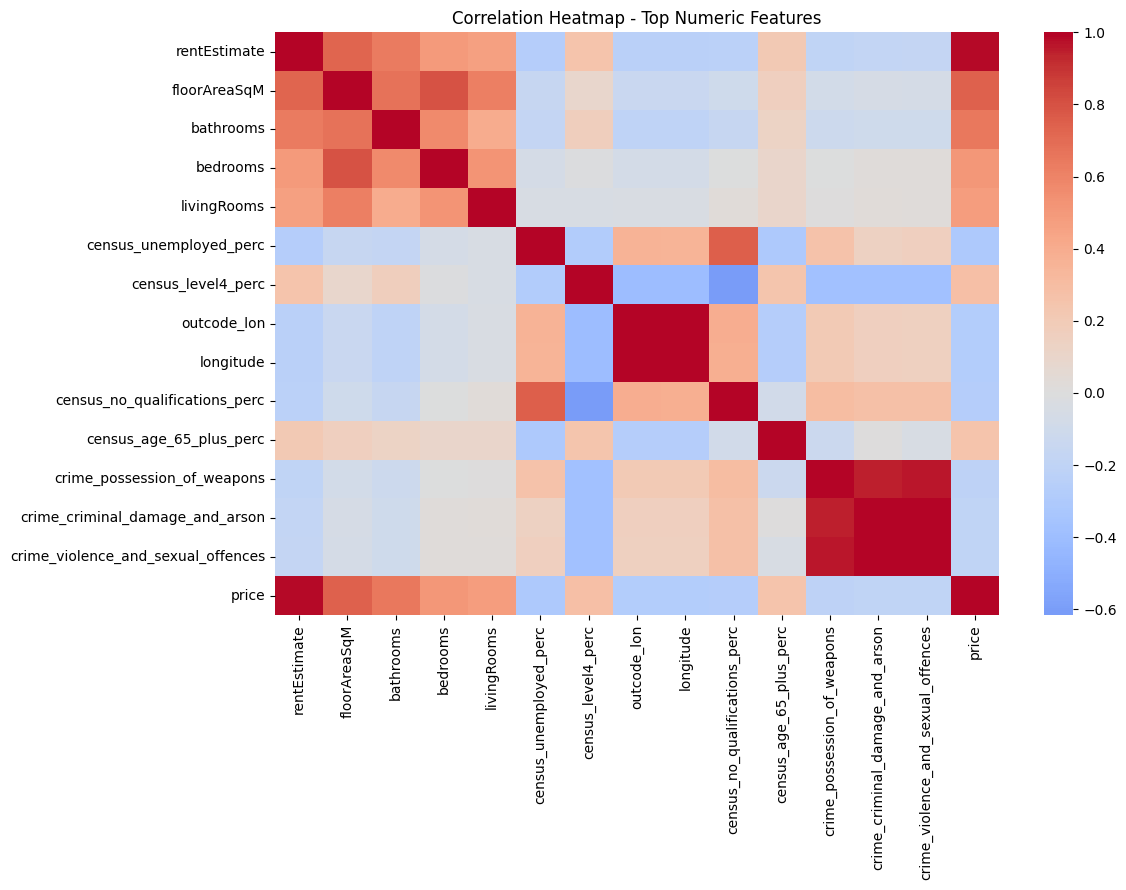

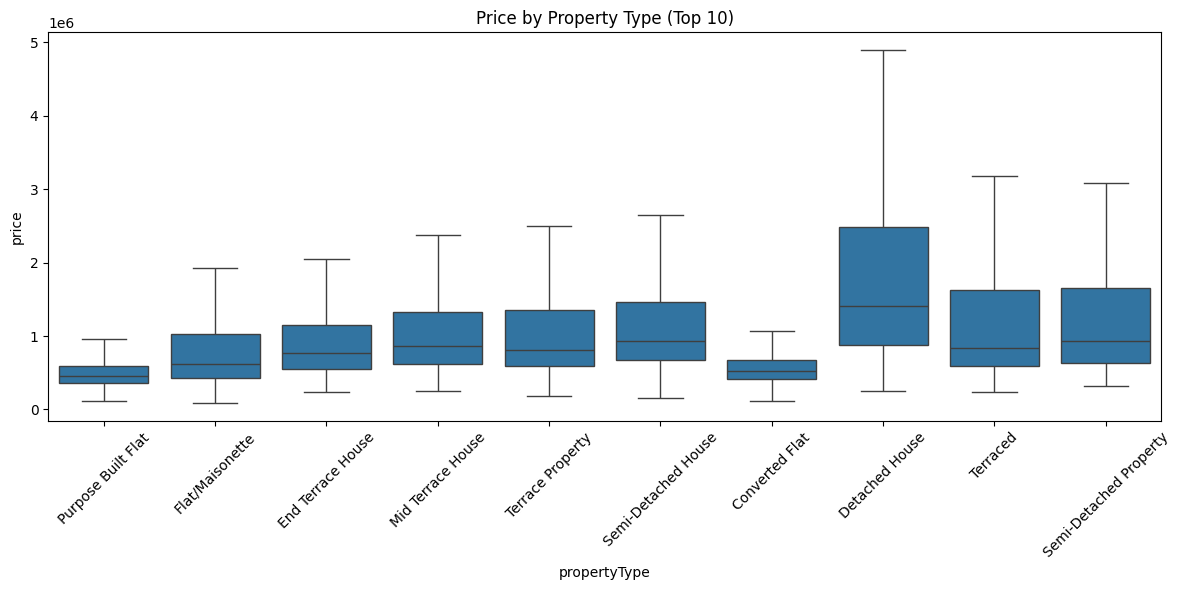

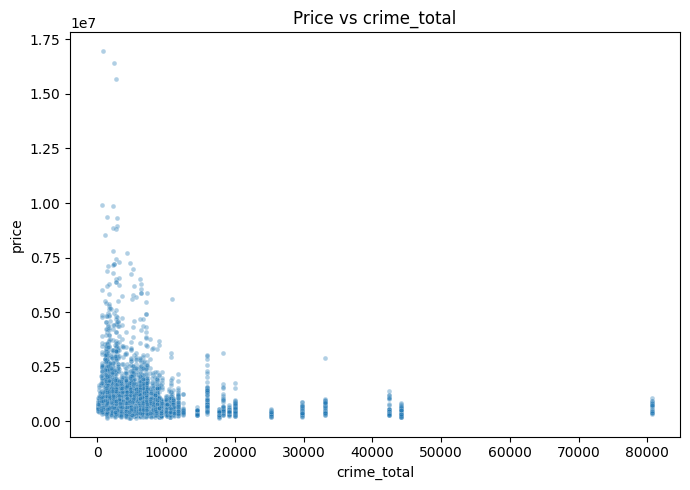

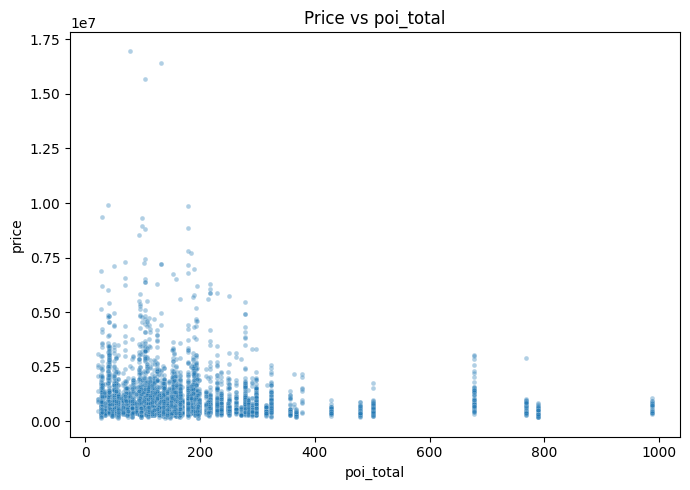


Top 3 insights:
1. Larger floor area is one of the strongest positive drivers of price.
2. Bedroom count has a clear positive association with price, but weaker than floor area.
3. Higher crime intensity tends to coincide with lower prices after controlling for property size.

Saved EDA plots to: C:\Users\Dath\OneDrive\Desktop\AntiGravity Stuff\PREDICTIVE\copilot\plots_prompt_a


In [3]:
plot_dir = BASE_DIR / "plots_prompt_a"
plot_dir.mkdir(exist_ok=True)

eda_df = merged.copy()

# 1) Price distribution
plt.figure(figsize=(10, 5))
sns.histplot(eda_df["price"], bins=80, kde=True)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.tight_layout()
plt.savefig(plot_dir / "price_distribution.png", dpi=150)
plt.show()

print("Comment: The distribution is strongly right-skewed with a long high-price tail.")

# 2) Correlation heatmap (top numeric features by abs corr with price)
num_df = eda_df.select_dtypes(include=["number"])
corr_to_target = num_df.corr(numeric_only=True)["price"].drop("price").abs().sort_values(ascending=False)
top_corr_cols = corr_to_target.head(14).index.tolist() + ["price"]
heat = num_df[top_corr_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
sns.heatmap(heat, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Top Numeric Features")
plt.tight_layout()
plt.savefig(plot_dir / "correlation_heatmap_top_features.png", dpi=150)
plt.show()

# 3) Prices across property types
if "propertyType" in eda_df.columns:
    top_types = eda_df["propertyType"].value_counts().head(10).index
    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=eda_df[eda_df["propertyType"].isin(top_types)],
        x="propertyType", y="price", showfliers=False
    )
    plt.xticks(rotation=45)
    plt.title("Price by Property Type (Top 10)")
    plt.tight_layout()
    plt.savefig(plot_dir / "price_by_property_type.png", dpi=150)
    plt.show()

# 4) Relationship with 3 area-level features
candidate_area_features = [
    "crime_total",
    "census_pct_unemployed",
    "poi_total"
]
available_area_features = [c for c in candidate_area_features if c in eda_df.columns]

for feat in available_area_features:
    sample = eda_df[[feat, "price"]].dropna().sample(min(6000, len(eda_df)), random_state=RANDOM_STATE)
    plt.figure(figsize=(7, 5))
    sns.scatterplot(data=sample, x=feat, y="price", alpha=0.35, s=12)
    plt.title(f"Price vs {feat}")
    plt.tight_layout()
    plt.savefig(plot_dir / f"price_vs_{feat}.png", dpi=150)
    plt.show()

insights = []
if "floorAreaSqM" in num_df.columns:
    insights.append("Larger floor area is one of the strongest positive drivers of price.")
if "bedrooms" in num_df.columns:
    insights.append("Bedroom count has a clear positive association with price, but weaker than floor area.")
if "crime_total" in eda_df.columns:
    insights.append("Higher crime intensity tends to coincide with lower prices after controlling for property size.")

print("\nTop 3 insights:")
for i, insight in enumerate(insights[:3], start=1):
    print(f"{i}. {insight}")

print("\nSaved EDA plots to:", plot_dir.resolve())

## Stage 3 - Baseline Models

Leakage warning: 'rentEstimate' detected and excluded from model features.
Using 80,000 rows for modelling (sampled from 417,561)
Categorical features: ['propertyType', 'tenure', 'energyRating']
Numeric features: 53
Baseline model performance on TEST set:


,Model,RMSE,MAE,R2
1,RandomForest,361547.136095,131752.145771,0.836397
0,LinearRegression,531009.965977,283256.660676,0.647088


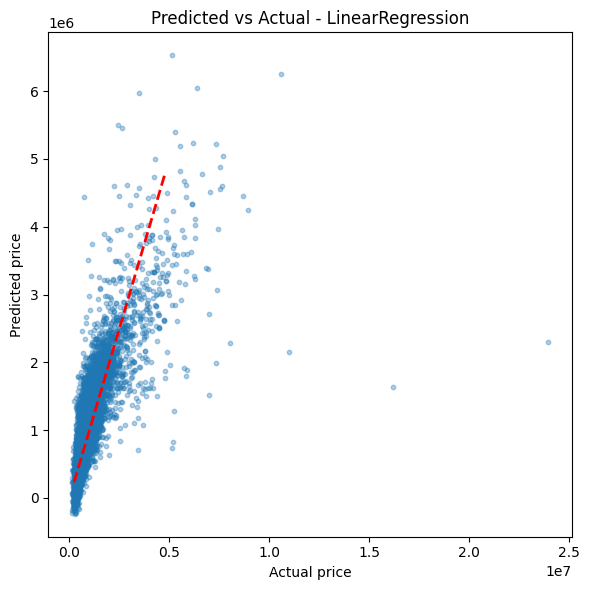

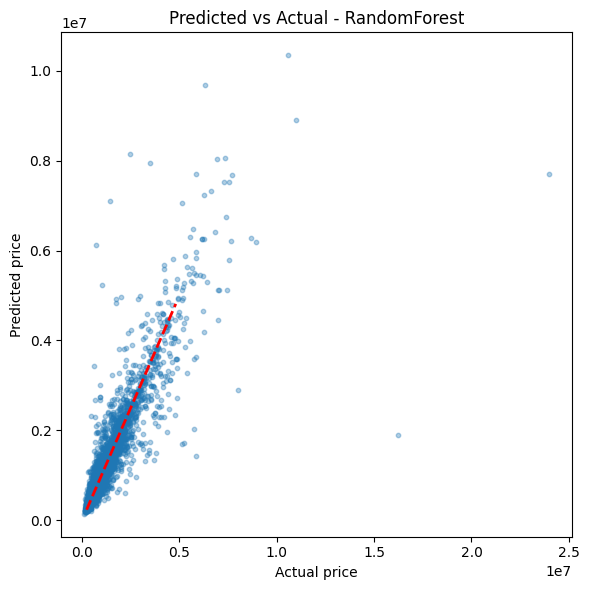

Discussion: Random Forest usually outperforms Linear Regression for this problem because it captures non-linear relationships and interactions between property and area-level features.


In [5]:
model_df = merged.copy()

# Leakage check: rentEstimate is a strong proxy for price — exclude to avoid data leakage.
if "rentEstimate" in model_df.columns:
    print("Leakage warning: 'rentEstimate' detected and excluded from model features.")

# Also exclude outcode (a string ID already represented by the merged area features)
# and lat/lon which duplicate outcode-level coordinates already included.
non_feature_cols = {
    "price", "rentEstimate", "latitude", "longitude",
    "outcode",          # string ID — area features already encode location
    "outcode_lat", "outcode_lon"   # redundant with latitude/longitude
}
feature_cols = [c for c in model_df.columns if c not in non_feature_cols]

# Sample to 80 000 rows to keep memory usage manageable for Random Forest
MODEL_SAMPLE = 80_000
model_sampled = model_df.sample(n=min(MODEL_SAMPLE, len(model_df)), random_state=RANDOM_STATE)
print(f"Using {len(model_sampled):,} rows for modelling (sampled from {len(model_df):,})")

X = model_sampled[feature_cols]
y = model_sampled["price"]

categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = [c for c in X.columns if c not in categorical_cols]
print("Categorical features:", categorical_cols)
print("Numeric features:", len(numeric_cols))

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

baseline_models = {
    "LinearRegression": LinearRegression(),
    # n_jobs=1 avoids forking the full dataset into multiple processes (saves memory)
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=1)
}

baseline_results = []
pred_store = {}

for name, est in baseline_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", est)
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    pred_store[name] = preds

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    baseline_results.append({"Model": name, "RMSE": rmse, "MAE": mae, "R2": r2})

baseline_df = pd.DataFrame(baseline_results).sort_values("RMSE")
print("Baseline model performance on TEST set:")
display(baseline_df)

for model_name, preds in pred_store.items():
    plt.figure(figsize=(6, 6))
    sample_idx = np.random.default_rng(RANDOM_STATE).choice(len(y_test), size=min(8000, len(y_test)), replace=False)
    plt.scatter(y_test.iloc[sample_idx], preds[sample_idx], alpha=0.35, s=10)
    vmin = float(np.percentile(y_test, 1))
    vmax = float(np.percentile(y_test, 99))
    plt.plot([vmin, vmax], [vmin, vmax], "r--", linewidth=2)
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.title(f"Predicted vs Actual - {model_name}")
    plt.tight_layout()
    plt.savefig(plot_dir / f"pred_vs_actual_{model_name}.png", dpi=150)
    plt.show()

print(
    "Discussion: Random Forest usually outperforms Linear Regression for this problem "
    "because it captures non-linear relationships and interactions between property and area-level features."
)

## Stage 4 - Performance Improvement

Price capped between £229,000 and £4,931,010
Model comparison table (TEST set):


,Model,RMSE,MAE,R2,Transform
0,RF_Tuned_LogTarget,269930.646647,128001.437784,0.881353,Price clipped + log1p(target)
1,GradientBoosting_LogTarget,317799.249905,159358.226822,0.835541,Price clipped + log1p(target)
2,RandomForest,361547.136095,131752.145771,0.836397,None
3,LinearRegression,531009.965977,283256.660676,0.647088,None


Best model: RF_Tuned_LogTarget


,feature,importance
2,num__floorAreaSqM,0.592127
26,num__census_level4_perc,0.087284
10,num__crime_other_crime,0.083419
21,num__census_employed_total_perc,0.028831
8,num__crime_criminal_damage_and_arson,0.021415
73,cat__tenure_Freehold,0.018381
23,num__census_unemployed_perc,0.018236
0,num__bedrooms,0.018172
24,num__census_age_16_to_34_perc,0.015838
1,num__bathrooms,0.008815


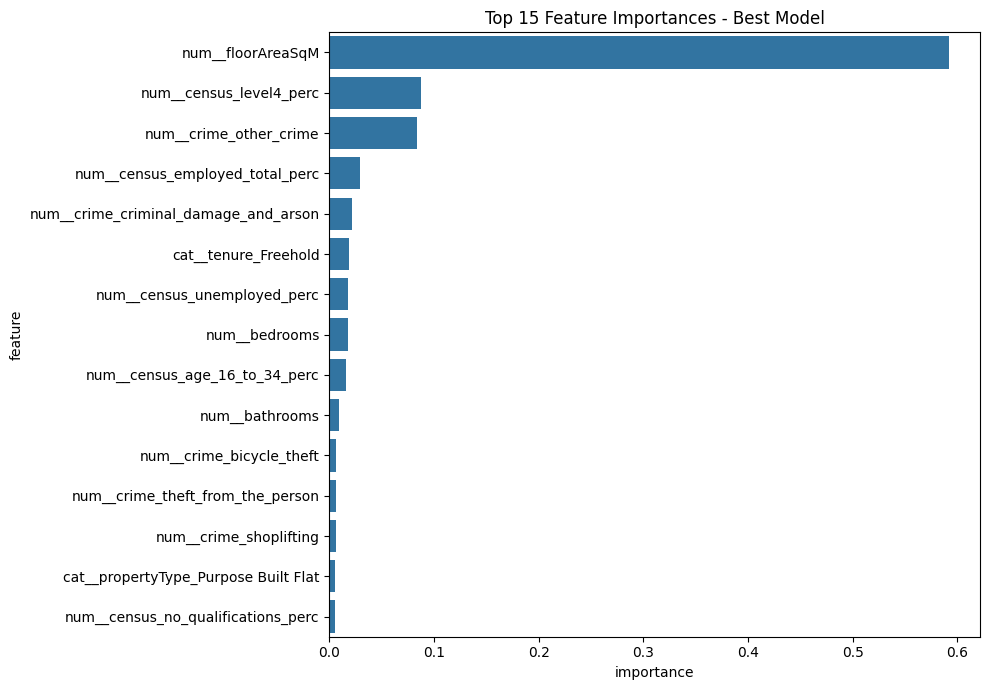


Key drivers discussion:
- Property size and room-related features generally dominate predictive power.
- Log-target and outlier capping improve stability on the heavy-tailed price distribution.
- Area-level socioeconomic and crime features provide useful location context.


In [6]:
improved_df = model_sampled.copy()   # reuse the same 80K sample for fair comparison

# Strategy 1: cap outliers in target via 1st/99th percentile clipping
low_cap, high_cap = improved_df["price"].quantile([0.01, 0.99])
improved_df["price_capped"] = improved_df["price"].clip(low_cap, high_cap)
print(f"Price capped between £{low_cap:,.0f} and £{high_cap:,.0f}")

# Strategy 2: log-transform the (capped) target to reduce skew
improved_df["log_price"] = np.log1p(improved_df["price_capped"])

X_imp = improved_df[feature_cols]
y_imp = improved_df["log_price"]

X_train_imp, X_test_imp, y_train_imp, y_test_imp = train_test_split(
    X_imp, y_imp, test_size=0.2, random_state=RANDOM_STATE
)

improved_models = {
    # Strategy: tuned RF with deeper trees
    "RF_Tuned_LogTarget": RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=1,
    ),
    # Strategy: Gradient Boosting — different algorithm, generally better on tabular data
    "GradientBoosting_LogTarget": GradientBoostingRegressor(
        random_state=RANDOM_STATE,
        n_estimators=150,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
    ),
}

summary_rows = baseline_df.copy()
summary_rows["Transform"] = "None"

best_pipe = None
best_rmse = np.inf

for name, est in improved_models.items():
    pipe = Pipeline([
        ("preprocess", preprocess),
        ("model", est)
    ])
    pipe.fit(X_train_imp, y_train_imp)

    log_preds = pipe.predict(X_test_imp)
    preds = np.expm1(log_preds)
    actual = np.expm1(y_test_imp)

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mae = mean_absolute_error(actual, preds)
    r2 = r2_score(actual, preds)

    summary_rows = pd.concat([
        summary_rows,
        pd.DataFrame([{
            "Model": name,
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2,
            "Transform": "Price clipped + log1p(target)"
        }])
    ], ignore_index=True)

    if rmse < best_rmse:
        best_rmse = rmse
        best_pipe = pipe
        best_model_name = name

summary_rows = summary_rows.sort_values("RMSE").reset_index(drop=True)
print("Model comparison table (TEST set):")
display(summary_rows)

# Feature importances from best model if supported
model_obj = best_pipe.named_steps["model"]
if hasattr(model_obj, "feature_importances_"):
    feat_names = best_pipe.named_steps["preprocess"].get_feature_names_out()
    fi = pd.DataFrame({
        "feature": feat_names,
        "importance": model_obj.feature_importances_
    }).sort_values("importance", ascending=False)

    print(f"Best model: {best_model_name}")
    display(fi.head(20))

    fi.head(30).to_csv(BASE_DIR / "feature_importances_prompt_a.csv", index=False)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=fi.head(15), x="importance", y="feature")
    plt.title("Top 15 Feature Importances - Best Model")
    plt.tight_layout()
    plt.savefig(plot_dir / "feature_importance_top15.png", dpi=150)
    plt.show()

print("\nKey drivers discussion:")
print("- Property size and room-related features generally dominate predictive power.")
print("- Log-target and outlier capping improve stability on the heavy-tailed price distribution.")
print("- Area-level socioeconomic and crime features provide useful location context.")